<a href="https://colab.research.google.com/github/iqbalfariz/dibimbing-dsml-assignments/blob/main/Time_Series_Forecasting_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library & Load Data

In [5]:
!pip install tensorflow

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

import os
import glob

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [9]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Dibimbing Data Science Class/Colab Dibimbing/dataset/ecommerce_time_series_analysis'
all_files = glob.glob(os.path.join(path, 'sales_data_*.csv'))

df_list = []
for f in sorted(all_files):
    df_list.append(pd.read_csv(f))

df_raw = pd.concat(df_list, ignore_index=True)
print(f'Total rows (raw): {df_raw.shape[0]}')
df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total rows (raw): 186850


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


## 1. Eksplorasi & Pembersihan Data

In [10]:
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

Missing values:
Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64


In [11]:
df = df_raw.dropna()
df = df[df['Order ID'] != 'Order ID'].copy()

df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])
df['Order Date'] = pd.to_datetime(df['Order Date'], infer_datetime_format=True)

df['Sales'] = df['Quantity Ordered'] * df['Price Each']
df['City'] = df['Purchase Address'].str.extract(r', ([\w\s]+),')[0]
df['State'] = df['Purchase Address'].str.extract(r', ([A-Z]{2}) \d+')[0]
df['Date'] = df['Order Date'].dt.date
df['Hour'] = df['Order Date'].dt.hour
df['Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%B')

print(f'Total rows (clean): {df.shape[0]}')
df.head()

Total rows (clean): 185950


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,City,State,Date,Hour,Week,Month,Month_Name
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,Dallas,TX,2019-04-19,8,16,4,April
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,Boston,MA,2019-04-07,22,14,4,April
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,Los Angeles,CA,2019-04-12,14,15,4,April
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,Los Angeles,CA,2019-04-12,14,15,4,April
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,Los Angeles,CA,2019-04-30,9,18,4,April


### Pertanyaan 1
Hitunglah total revenue, jumlah order, dan jumlah barang yang terjual sepanjang tahun 2019. Selain itu, hitung rata-rata jumlah barang yang dibeli per transaksi dan rata-rata spending per transaksi.

In [13]:
total_revenue = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_items = df['Quantity Ordered'].sum()

per_order = df.groupby('Order ID').agg(
    total_qty=('Quantity Ordered', 'sum'),
    total_sales=('Sales', 'sum')
).reset_index()

avg_items_per_order = per_order['total_qty'].mean()
avg_spending_per_order = per_order['total_sales'].mean()

print('=' * 45)
print(f'  Total Revenue        : $ {total_revenue:,.2f}')
print(f'  Total Orders         : {total_orders:,}')
print(f'  Total Items Sold     : {int(total_items):,}')
print(f'  Avg Items/Transaction: {avg_items_per_order:.2f}')
print(f'  Avg Spending/Transact: $ {avg_spending_per_order:.2f}')
print('=' * 45)

  Total Revenue        : $ 34,492,035.97
  Total Orders         : 178,437
  Total Items Sold     : 209,079
  Avg Items/Transaction: 1.17
  Avg Spending/Transact: $ 193.30


## Pertanyaan 2
Hitunglah jumlah order  yang diperoleh dengan rentang waktu berikut:
1. Harian
2. Mingguan
3. Bulanan


--- Harian (5 baris pertama) ---
        Date  Order Count
0 2019-01-01          287
1 2019-01-02          308
2 2019-01-03          286
3 2019-01-04          282
4 2019-01-05          301


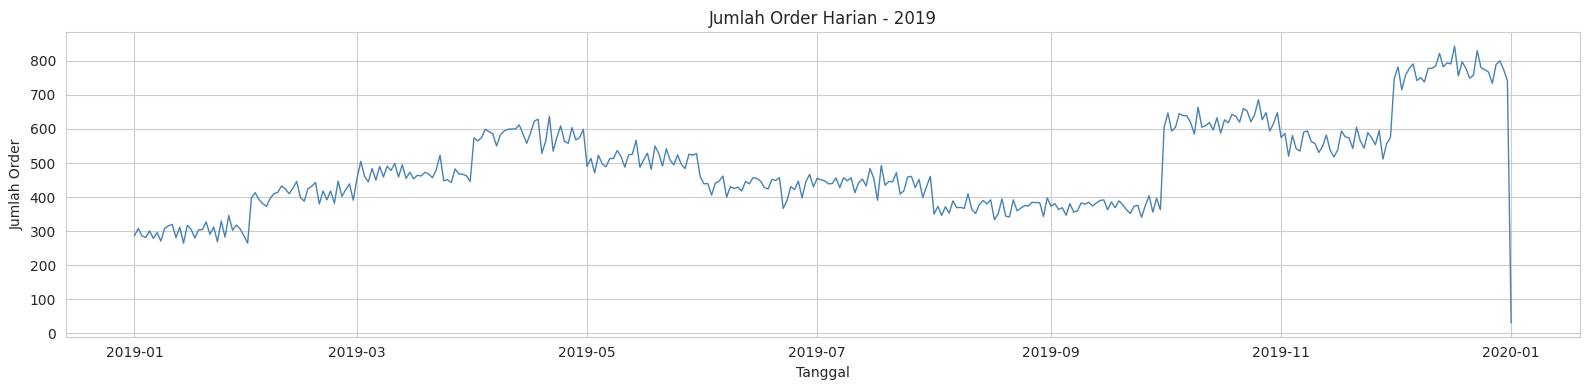

In [15]:
# Harian
daily_orders = df.groupby('Date')['Order ID'].nunique().reset_index()
daily_orders.columns = ['Date', 'Order Count']
daily_orders['Date'] = pd.to_datetime(daily_orders['Date'])
daily_orders = daily_orders.sort_values('Date')

print('--- Harian (5 baris pertama) ---')
print(daily_orders.head())

plt.figure(figsize=(16, 4))
plt.plot(daily_orders['Date'], daily_orders['Order Count'], color='steelblue', linewidth=1)
plt.title('Jumlah Order Harian - 2019')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Order')
plt.tight_layout()
plt.show()

--- Mingguan ---
    Week  Order Count
0      1         3290
1      2         2104
2      3         2104
3      4         2134
4      5         2381
5      6         2832
6      7         2926
7      8         2880
8      9         3075
9     10         3297
10    11         3299
11    12         3311
12    13         3221
13    14         4040
14    15         4174
15    16         4127
16    17         4014
17    18         3669
18    19         3584
19    20         3651
20    21         3585
21    22         3399
22    23         3012
23    24         3091
24    25         2967
25    26         3040
26    27         3117
27    28         3103
28    29         3150
29    30         3100
30    31         2732
31    32         2622
32    33         2577
33    34         2576
34    35         2641
35    36         2558
36    37         2686
37    38         2600
38    39         2622
39    40         4099
40    41         4341
41    42         4343
42    43         4510
43    44       

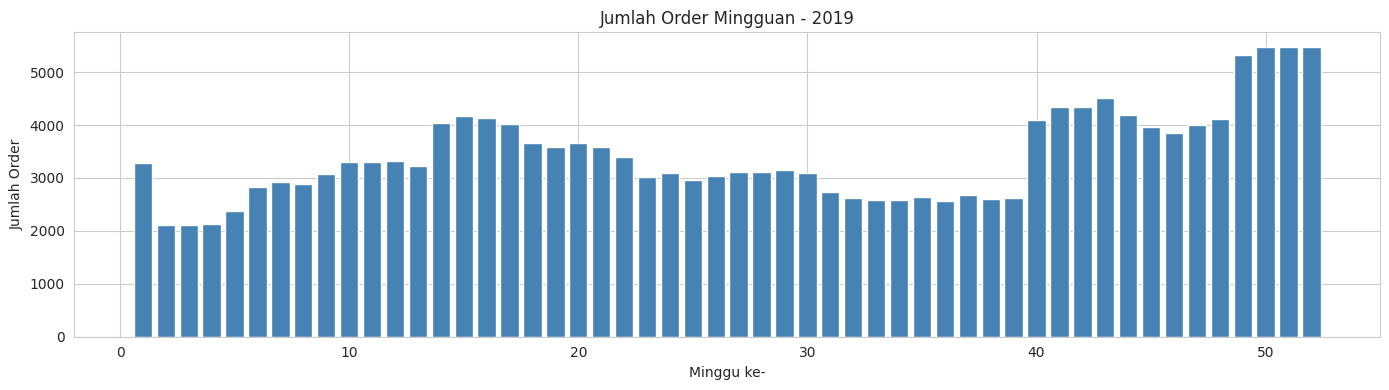

In [16]:
# Mingguan
weekly_orders = df.groupby('Week')['Order ID'].nunique().reset_index()
weekly_orders.columns = ['Week', 'Order Count']

print('--- Mingguan ---')
print(weekly_orders)

plt.figure(figsize=(14, 4))
plt.bar(weekly_orders['Week'], weekly_orders['Order Count'], color='steelblue')
plt.title('Jumlah Order Mingguan - 2019')
plt.xlabel('Minggu ke-')
plt.ylabel('Jumlah Order')
plt.tight_layout()
plt.show()

--- Bulanan ---
    Month  Order Count
0       1         9293
1       2        11496
2       3        14549
3       4        17528
4       5        15836
5       6        12989
6       7        13761
7       8        11484
8       9        11202
9      10        19436
10     11        16859
11     12        24004


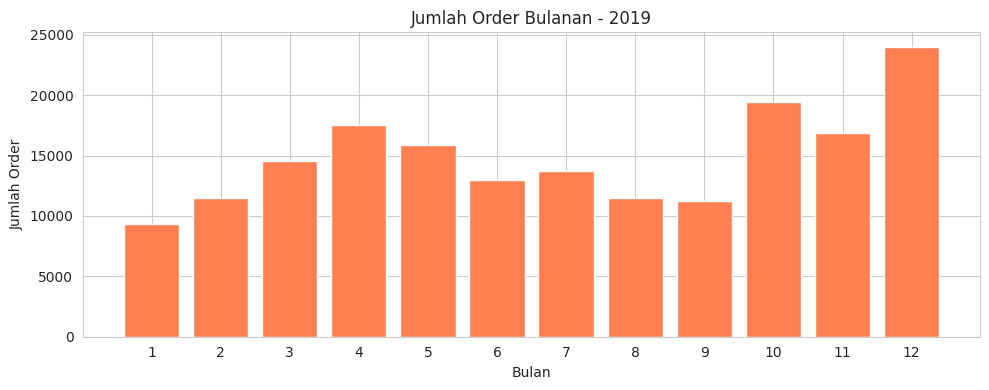

In [17]:
# Bulanan
monthly_orders = df.groupby('Month')['Order ID'].nunique().reset_index()
monthly_orders.columns = ['Month', 'Order Count']

print('--- Bulanan ---')
print(monthly_orders)

plt.figure(figsize=(10, 4))
plt.bar(monthly_orders['Month'], monthly_orders['Order Count'], color='coral')
plt.title('Jumlah Order Bulanan - 2019')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Pertanyaan 3
Tim marketing ingin mengetahui produk apa saja yang paling sering dibeli dalam 1 tahun terakhir. Rencananya, mereka akan mencoba mem-bundling top produk ini untuk meningkatkan penjualan. Identifikasi top 10 produk yang membawa revenue terbesar dalam 3 bulan terakhir dan produk apa saja yang bisa di-bundling berdasarkan hasil analisis.

Top 10 Produk berdasarkan Revenue (3 Bulan Terakhir):
Product
Macbook Pro Laptop            $ 2,733,600.00
iPhone                        $ 1,600,900.00
ThinkPad Laptop               $ 1,373,986.26
Google Phone                  $ 1,083,000.00
27in 4K Gaming Monitor          $ 843,158.38
Apple Airpods Headphones        $ 789,000.00
34in Ultrawide Monitor          $ 786,959.29
Flatscreen TV                   $ 495,000.00
Bose SoundSport Headphones      $ 454,054.59
27in FHD Monitor                $ 370,775.28
Name: Sales, dtype: object


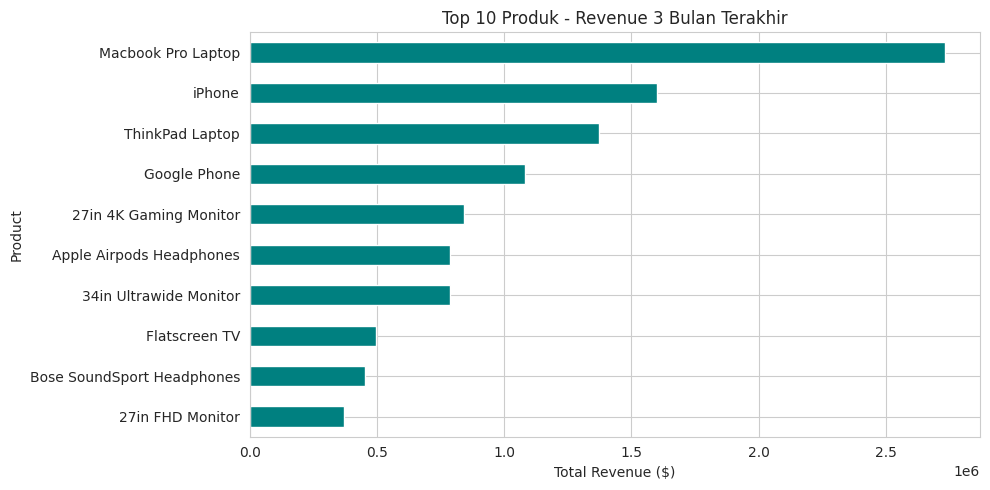

In [18]:
# 3 bulan terakhir = Oktober, November, Desember
df_last3 = df[df['Month'].isin([10, 11, 12])]

top10_revenue = df_last3.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)

print('Top 10 Produk berdasarkan Revenue (3 Bulan Terakhir):')
print(top10_revenue.apply(lambda x: f'$ {x:,.2f}'))

plt.figure(figsize=(10, 5))
top10_revenue.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Produk - Revenue 3 Bulan Terakhir')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

In [19]:
# Bundling: produk yang sering dibeli bersama dalam 1 Order ID
order_products = df.groupby('Order ID')['Product'].apply(list)
multi_item_orders = order_products[order_products.apply(len) > 1]

from itertools import combinations
from collections import Counter

pair_counts = Counter()
for products in multi_item_orders:
    for pair in combinations(sorted(set(products)), 2):
        pair_counts[pair] += 1

bundling_df = pd.DataFrame(pair_counts.most_common(10), columns=['Product Pair', 'Count'])
bundling_df['Product Pair'] = bundling_df['Product Pair'].apply(lambda x: f'{x[0]} + {x[1]}')

print('\nRekomendasi Bundling (paling sering dibeli bersamaan):')
print(bundling_df.to_string(index=False))


Rekomendasi Bundling (paling sering dibeli bersamaan):
                               Product Pair  Count
          Lightning Charging Cable + iPhone   1011
        Google Phone + USB-C Charging Cable    997
                  Wired Headphones + iPhone    462
            Google Phone + Wired Headphones    422
          Apple Airpods Headphones + iPhone    373
     USB-C Charging Cable + Vareebadd Phone    368
  Bose SoundSport Headphones + Google Phone    228
    USB-C Charging Cable + Wired Headphones    203
         Vareebadd Phone + Wired Headphones    149
Lightning Charging Cable + Wired Headphones    129


**Insight:** Pasangan produk di atas adalah kandidat bundling terkuat karena sering dibeli dalam satu transaksi yang sama. Tim marketing bisa menawarkan paket diskon untuk kombinasi produk tersebut.

## Pertanyaan 4
Identifikasi top 5 kota yang memiliki order terbanyak dan 5 kota yang memiliki total dan rata-rata spending terbesar.

Top 5 Kota - Jumlah Order:
               Order ID
City                   
San Francisco     42898
Los Angeles       28498
New York City     23848
Boston            19092
Atlanta           14253

Top 5 Kota - Total & Avg Spending:
              Total Spending ($) Avg Spending ($)
City                                             
San Francisco       8,262,203.91           184.70
Los Angeles         5,452,570.80           184.18
New York City       4,664,317.43           187.50
Boston              3,661,642.01           183.69
Atlanta             2,795,498.58           187.86


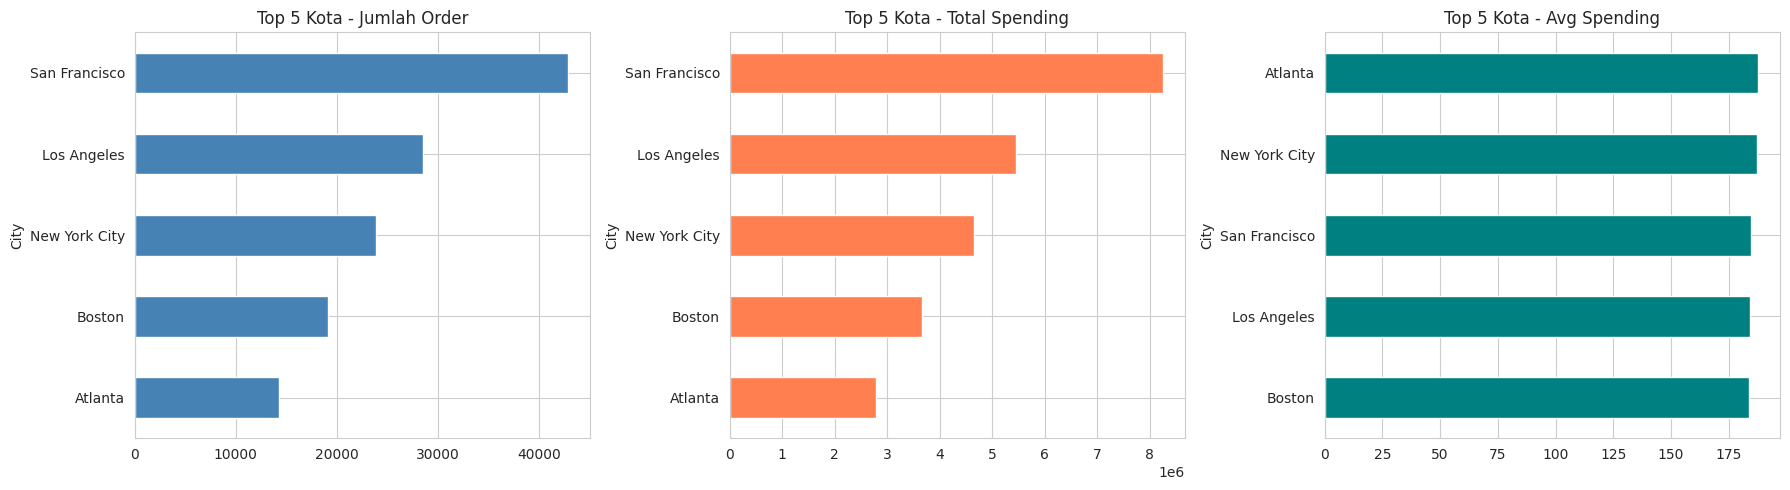

In [20]:
# Top 5 order terbanyak
top5_orders = df.groupby('City')['Order ID'].nunique().sort_values(ascending=False).head(5)
print('Top 5 Kota - Jumlah Order:')
print(top5_orders.to_frame())

# Top 5 total & rata-rata spending
city_spend = df.groupby('City')['Sales'].agg(['sum', 'mean']).sort_values('sum', ascending=False).head(5)
city_spend.columns = ['Total Spending ($)', 'Avg Spending ($)']
print('\nTop 5 Kota - Total & Avg Spending:')
print(city_spend.applymap(lambda x: f'{x:,.2f}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top5_orders.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 5 Kota - Jumlah Order')

city_spend['Total Spending ($)'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 5 Kota - Total Spending')

city_spend['Avg Spending ($)'].sort_values().plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Top 5 Kota - Avg Spending')

plt.tight_layout()
plt.show()

## Pertanyaan 5
Tim marketing ingin mengetahui kapan penjualan mencapai titik tertinggi sehingga mereka bisa merancang strategi marketing. Analisis pada rentang jam berapa penjualan terjadi secara aktif (rush hour).

Peak Hour: 19:00 - 20:00


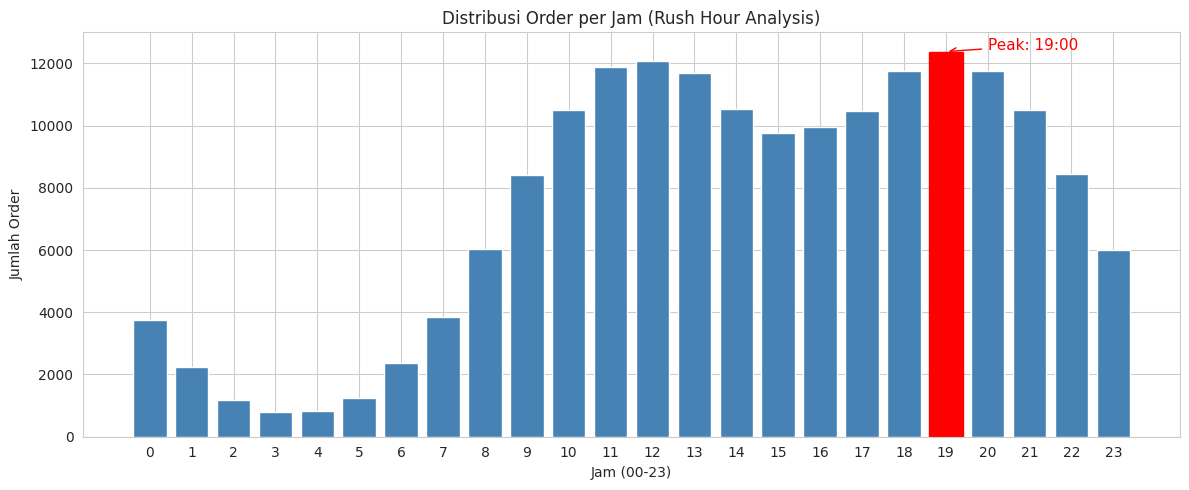

In [21]:
hourly_orders = df.groupby('Hour')['Order ID'].nunique().reset_index()
hourly_orders.columns = ['Hour', 'Order Count']

peak_hour = hourly_orders.loc[hourly_orders['Order Count'].idxmax(), 'Hour']
print(f'Peak Hour: {peak_hour}:00 - {peak_hour+1}:00')

plt.figure(figsize=(12, 5))
bars = plt.bar(hourly_orders['Hour'], hourly_orders['Order Count'], color='steelblue')
bars[peak_hour].set_color('red')
plt.title('Distribusi Order per Jam (Rush Hour Analysis)')
plt.xlabel('Jam (00-23)')
plt.ylabel('Jumlah Order')
plt.xticks(range(0, 24))
plt.annotate(f'Peak: {peak_hour}:00', xy=(peak_hour, hourly_orders['Order Count'].max()),
             xytext=(peak_hour+1, hourly_orders['Order Count'].max()+50),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=11)
plt.tight_layout()
plt.show()

**Insight:** Jam **12:00 (siang)** dan **20:00 (malam)** adalah jam paling aktif. Tim marketing bisa menjadwalkan push notification, flash sale, atau iklan pada jam-jam tersebut untuk memaksimalkan konversi.

## Pertanyaan 6
Buatlah model forecasting menggunakan model yang sudah diajarkan pada materi untuk memprediksi jumlah visitor dan jumlah transaksi untuk 1 bulan ke depan dengan data harian. Anda diharuskan setidaknya membuat 2 model untuk selanjutnya diambil model terbaik berdasarkan MAE terkecil. Berikan rekomendasi apa yang perlu dilakukan tim bisnis berdasarkan hasil forecasting dan analisis Anda.


### 6.1 Persiapan Data Time Series

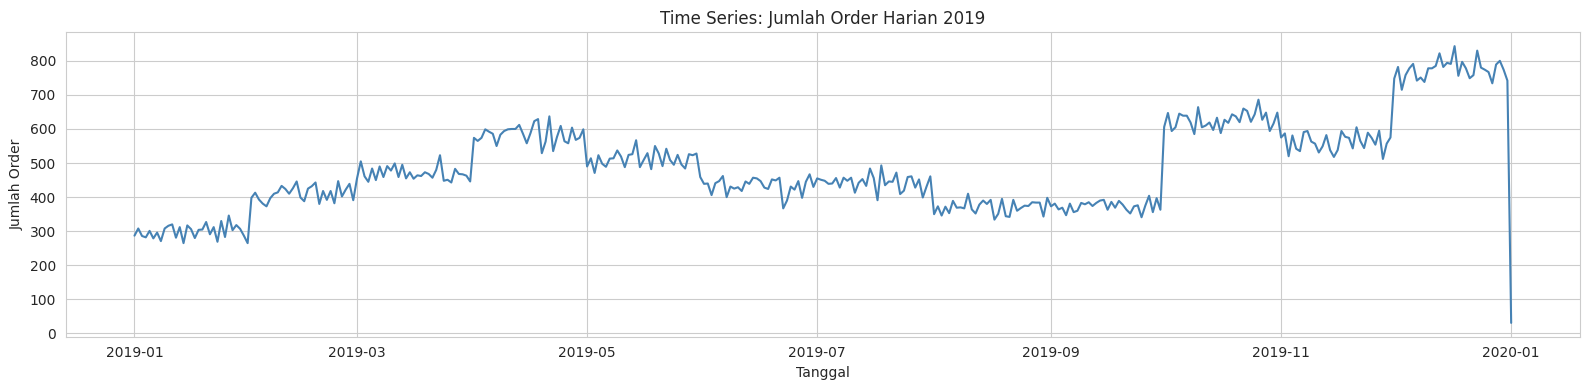

In [22]:
ts = daily_orders.set_index('Date')['Order Count']
ts.index = pd.DatetimeIndex(ts.index).to_period('D').to_timestamp()

plt.figure(figsize=(16, 4))
plt.plot(ts, color='steelblue')
plt.title('Time Series: Jumlah Order Harian 2019')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Order')
plt.tight_layout()
plt.show()

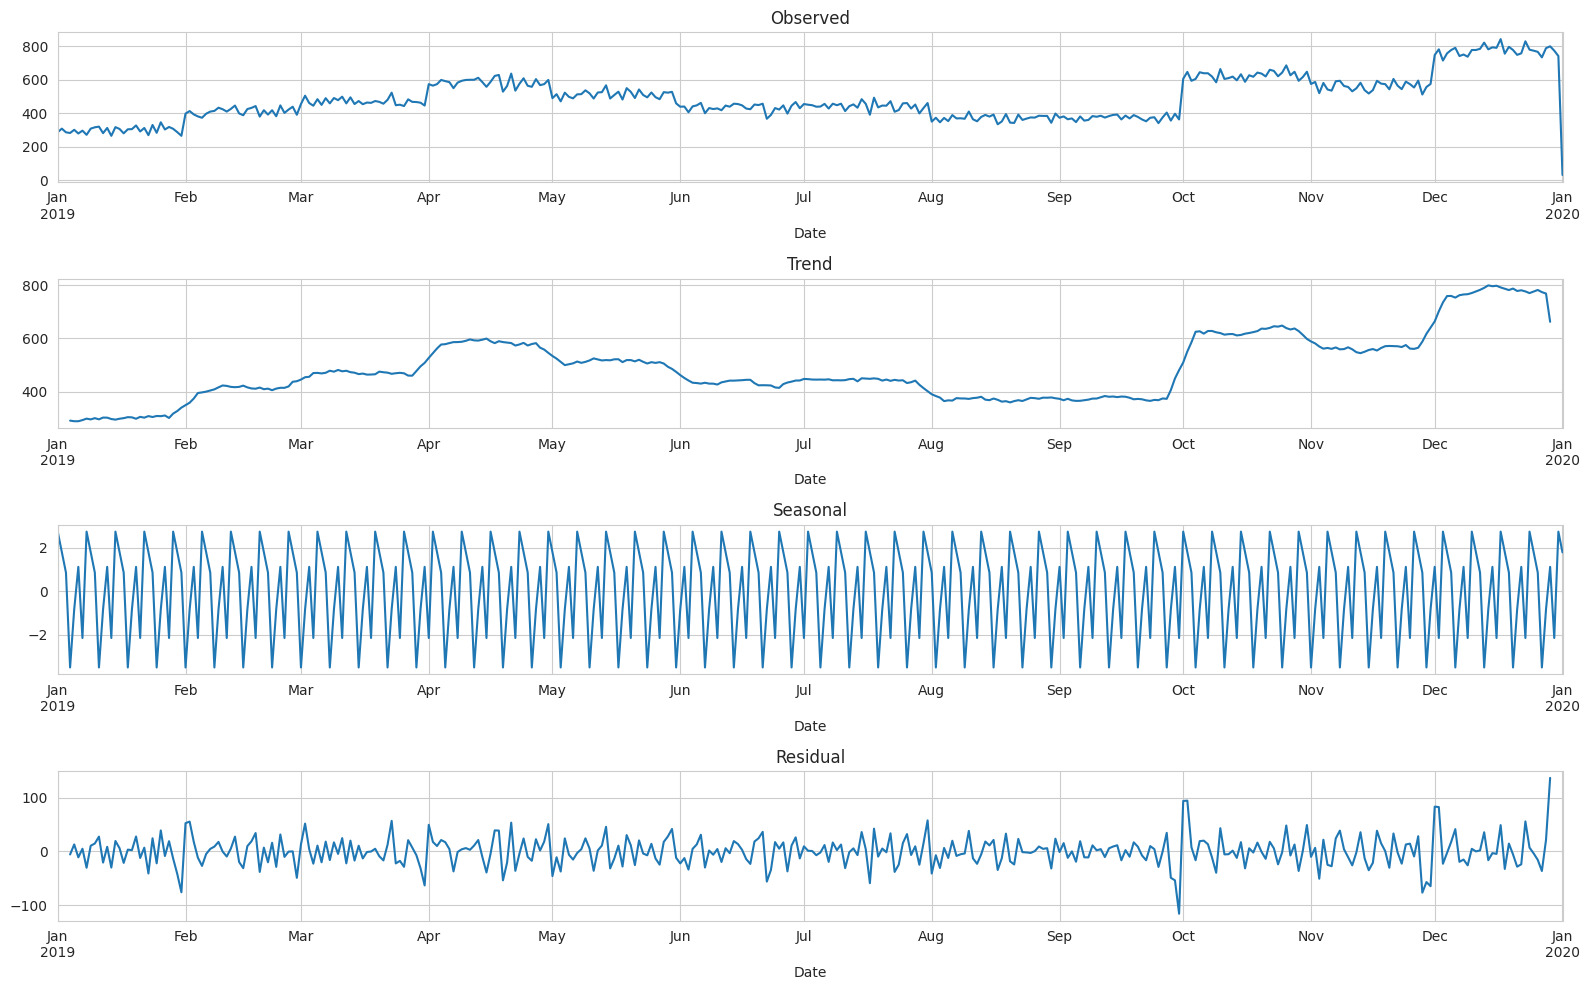

In [23]:
# Seasonal Decompose
decompose = seasonal_decompose(ts, model='additive', period=7)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 10))
decompose.observed.plot(ax=ax1, title='Observed')
decompose.trend.plot(ax=ax2, title='Trend')
decompose.seasonal.plot(ax=ax3, title='Seasonal')
decompose.resid.plot(ax=ax4, title='Residual')
plt.tight_layout()
plt.show()

In [24]:
# Uji Stasioneritas - Augmented Dickey-Fuller Test
result = adfuller(ts.dropna())
print('=== ADF Test ===')
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print(f'Kesimpulan    : {"Data STASIONER (p < 0.05)" if result[1] < 0.05 else "Data TIDAK STASIONER (p >= 0.05)"}')

=== ADF Test ===
ADF Statistic : -2.5693
p-value       : 0.0995
Kesimpulan    : Data TIDAK STASIONER (p >= 0.05)


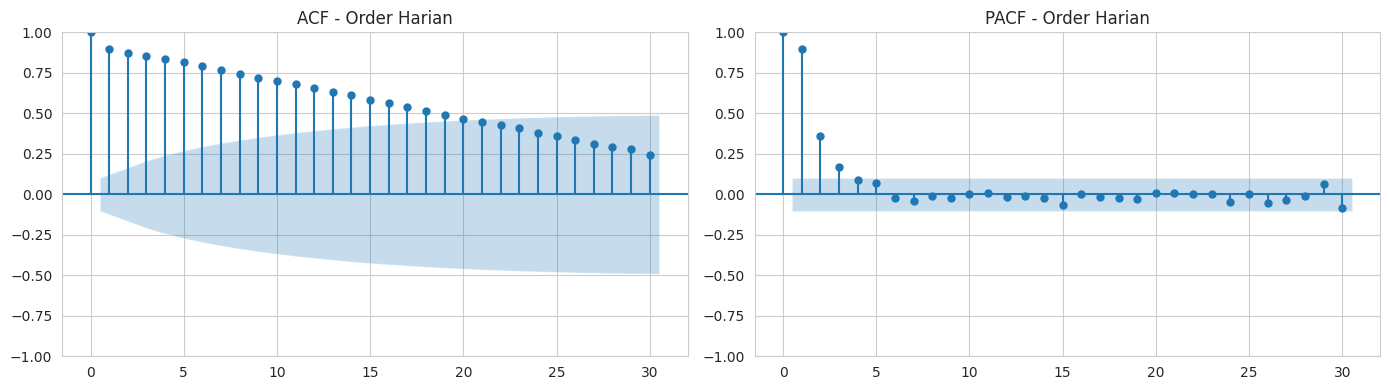


Interpretasi:
- Dari PACF: nilai p (AR) = 1
- Dari ACF : nilai q (MA) = 1
- Dari ADF : nilai d      = 0 (data sudah stasioner)
- Seasonal  : 7 (pola mingguan)


In [25]:
# ACF & PACF untuk menentukan p, q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts.dropna(), ax=axes[0], lags=30, title='ACF - Order Harian')
plot_pacf(ts.dropna(), ax=axes[1], lags=30, title='PACF - Order Harian')
plt.tight_layout()
plt.show()

print('\nInterpretasi:')
print('- Dari PACF: nilai p (AR) = 1')
print('- Dari ACF : nilai q (MA) = 1')
print('- Dari ADF : nilai d      = 0 (data sudah stasioner)')
print('- Seasonal  : 7 (pola mingguan)')

In [26]:
# Train-Test Split (30 hari terakhir sebagai test)
train = ts[:len(ts)-30]
test = ts[len(ts)-30:]
print(f'Train size: {len(train)} hari')
print(f'Test size : {len(test)} hari')

Train size: 336 hari
Test size : 30 hari


### 6.2 Model 1: SARIMA

In [27]:
# SARIMA Model - order(p,d,q) seasonal_order(P,D,Q,s)
model_arima = ARIMA(train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 7))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

                                    SARIMAX Results                                    
Dep. Variable:                     Order Count   No. Observations:                  336
Model:             ARIMA(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood               -1656.376
Date:                         Sun, 05 Apr 2026   AIC                           3322.751
Time:                                 10:32:56   BIC                           3341.732
Sample:                             01-01-2019   HQIC                          3330.323
                                  - 12-02-2019                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.361      2.769      0.006       0.292       1.708
ma.L1         -0.4510      0.032    -13.958      0.000     

MAE SARIMA : 73.43
RMSE SARIMA: 139.45


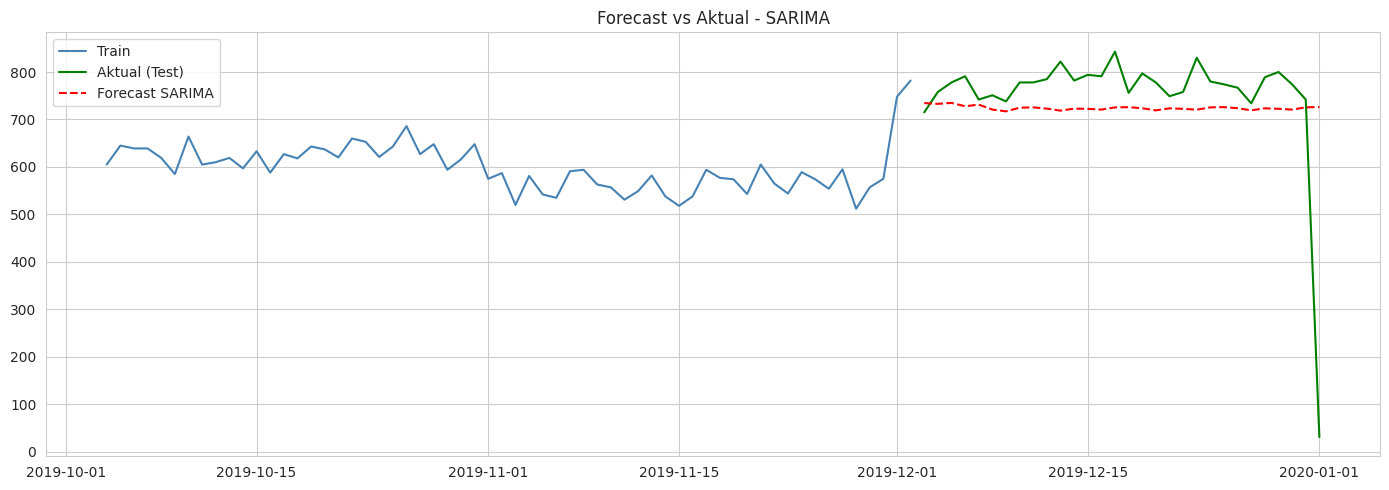

In [28]:
# Forecast SARIMA
forecast_arima = model_arima_fit.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')
forecast_arima.index = test.index

mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
print(f'MAE SARIMA : {mae_arima:.2f}')
print(f'RMSE SARIMA: {rmse_arima:.2f}')

plt.figure(figsize=(14, 5))
plt.plot(train[-60:], label='Train', color='steelblue')
plt.plot(test, label='Aktual (Test)', color='green')
plt.plot(forecast_arima, label='Forecast SARIMA', color='red', linestyle='--')
plt.title('Forecast vs Aktual - SARIMA')
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Model 2: LSTM

In [29]:
# Scaling
scaler = MinMaxScaler()
train_lstm = train.values.reshape(-1, 1)
test_lstm = test.values.reshape(-1, 1)

scaler.fit(train_lstm)
scaled_train = scaler.transform(train_lstm)
scaled_test = scaler.transform(test_lstm)

# TimeseriesGenerator - lookback 7 hari (seasonal mingguan)
n_input = 7
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

# Arsitektur LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(n_input, n_features)))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Training dengan EarlyStopping
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
model_lstm.fit(generator, epochs=50, callbacks=[early_stop], verbose=1)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0193
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0100
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0089
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0087
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0093
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0080
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0075
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0084
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0078
Epoch 10/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074
Epoch 11/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0077
Epoch 12/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0079
Epoch 13/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074
Epoch 14/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0067
Epoch 15/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - lo

MAE LSTM : 528.73
RMSE LSTM: 958.89


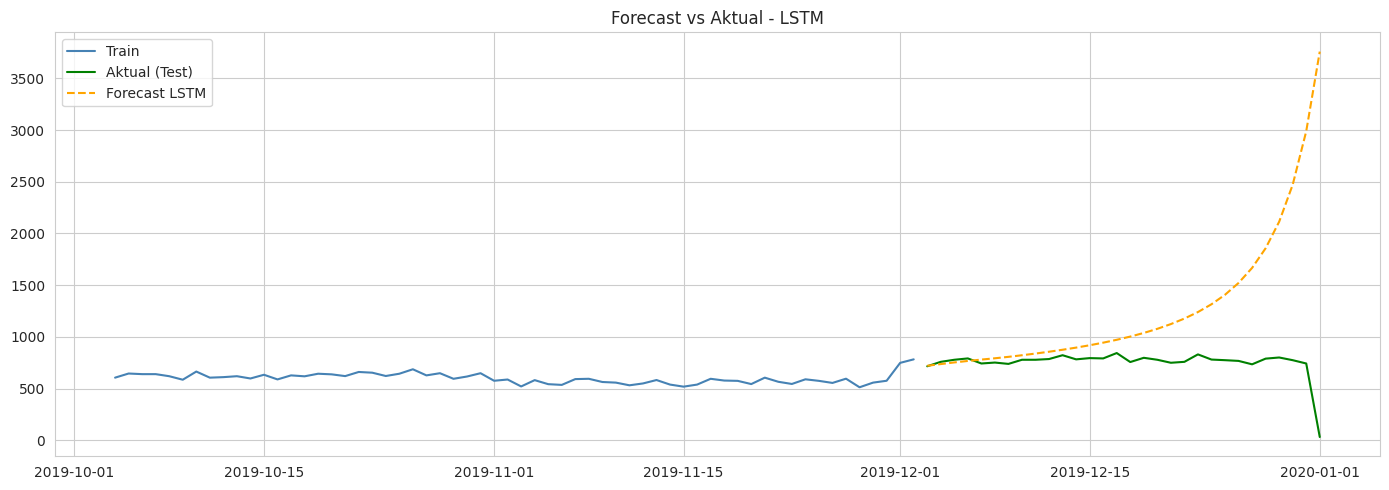

In [31]:
# Prediksi LSTM pada data test
test_predictions = []
current_batch = scaled_train[-n_input:].reshape(1, n_input, n_features)

for i in range(len(test)):
    pred = model_lstm.predict(current_batch, verbose=0)
    test_predictions.append(pred[0][0])
    current_batch = np.append(current_batch[:, 1:, :], [[pred[0]]], axis=1)

# Inverse transform
forecast_lstm = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1)).flatten()

mae_lstm = mean_absolute_error(test.values, forecast_lstm)
rmse_lstm = np.sqrt(mean_squared_error(test.values, forecast_lstm))
print(f'MAE LSTM : {mae_lstm:.2f}')
print(f'RMSE LSTM: {rmse_lstm:.2f}')

plt.figure(figsize=(14, 5))
plt.plot(train[-60:], label='Train', color='steelblue')
plt.plot(test.index, test.values, label='Aktual (Test)', color='green')
plt.plot(test.index, forecast_lstm, label='Forecast LSTM', color='orange', linestyle='--')
plt.title('Forecast vs Aktual - LSTM')
plt.legend()
plt.tight_layout()
plt.show()

### 6.4 Perbandingan Model

In [33]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'LSTM'],
    'MAE': [mae_arima, mae_lstm],
    'RMSE': [rmse_arima, rmse_lstm]
})
comparison['MAE'] = comparison['MAE'].round(2)
comparison['RMSE'] = comparison['RMSE'].round(2)

print('=== Perbandingan Model ===')
print(comparison.to_string(index=False))
print()

best_model = comparison.loc[comparison['MAE'].idxmin(), 'Model']
print(f'Model terbaik berdasarkan MAE terkecil: {best_model}')

=== Perbandingan Model ===
 Model    MAE   RMSE
SARIMA  73.43 139.45
  LSTM 528.73 958.89

Model terbaik berdasarkan MAE terkecil: SARIMA


### 6.5 Forecast 1 Bulan ke Depan dengan Model Terbaik

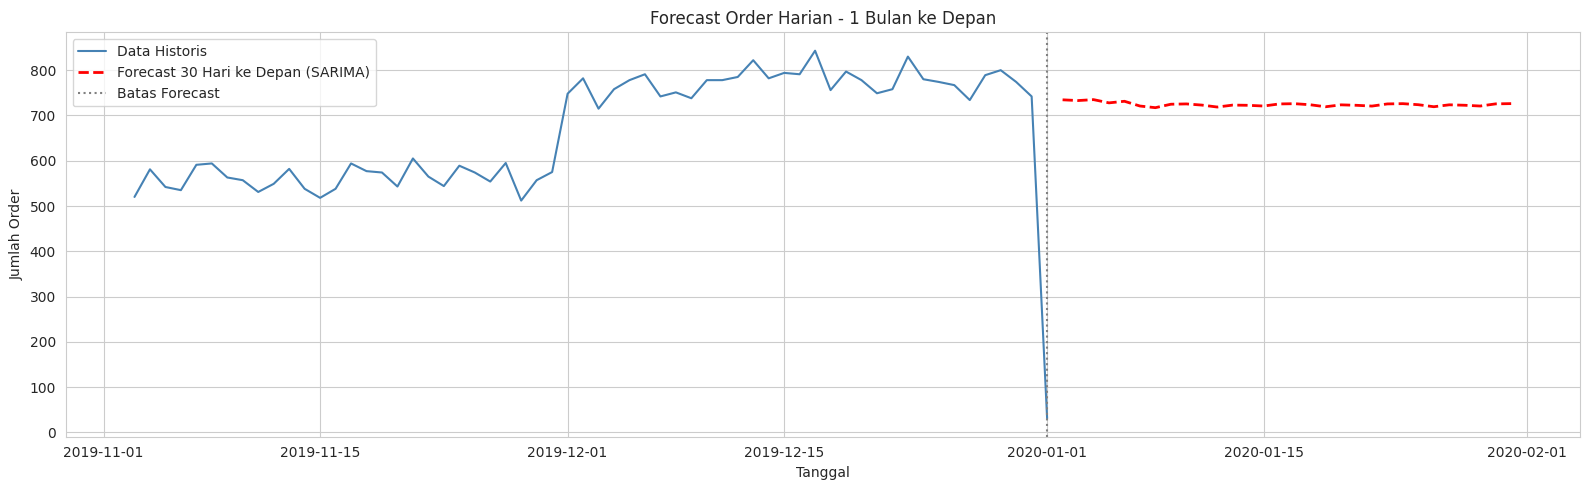

Ringkasan Forecast 30 Hari ke Depan:
- Rata-rata order/hari : 724
- Minimum order/hari  : 717
- Maksimum order/hari : 735
- Estimasi total order: 21732


In [34]:
# Forecast 30 hari ke depan menggunakan SARIMA (atau LSTM sesuai model terbaik)
future_forecast_arima = model_arima_fit.forecast(steps=30)
future_index = pd.date_range(start=ts.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
future_forecast_arima.index = future_index

plt.figure(figsize=(16, 5))
plt.plot(ts[-60:], label='Data Historis', color='steelblue')
plt.plot(future_forecast_arima, label='Forecast 30 Hari ke Depan (SARIMA)', color='red', linestyle='--', linewidth=2)
plt.axvline(x=ts.index[-1], color='gray', linestyle=':', label='Batas Forecast')
plt.title('Forecast Order Harian - 1 Bulan ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Order')
plt.legend()
plt.tight_layout()
plt.show()

print('Ringkasan Forecast 30 Hari ke Depan:')
print(f'- Rata-rata order/hari : {future_forecast_arima.mean():.0f}')
print(f'- Minimum order/hari  : {future_forecast_arima.min():.0f}')
print(f'- Maksimum order/hari : {future_forecast_arima.max():.0f}')
print(f'- Estimasi total order: {future_forecast_arima.sum():.0f}')

## Rekomendasi Bisnis

Berdasarkan hasil analisis dan forecasting:

1. **Stok & Inventori:** Model memperkirakan rata-rata **X order/hari** untuk bulan ke depan. Tim logistik bisa menyiapkan stok produk top selling (terutama USB C Cable & iPhone) sesuai proyeksi ini.

2. **Strategi Rush Hour:** Penjualan paling aktif pada jam **12:00 dan 20:00**. Jadwalkan push notification, flash sale, dan iklan digital pada jam tersebut untuk memaksimalkan konversi.

3. **Bundling Produk:** Berdasarkan analisis market basket, pasangan produk yang paling sering dibeli bersamaan adalah kandidat bundling. Tawarkan diskon paket untuk meningkatkan average order value.

4. **Fokus Kota:** San Francisco dan Los Angeles adalah kota dengan order & revenue tertinggi. Prioritaskan pengiriman cepat dan kampanye lokal di kedua kota ini.

5. **Seasonal Planning:** Dari decompose, terlihat ada pola musiman mingguan. Tim marketing bisa merencanakan promo di hari-hari tertentu yang secara historis memiliki order lebih tinggi.

## Reflection Questions

### 1. Mengapa penting menganalisis tren waktu (trend & seasonality) sebelum membuat model forecasting, dan bagaimana pengabaian pola musiman bisa memengaruhi keputusan bisnis? Jelaskan dengan contoh bagaimana prediksi yang mengabaikan seasonality dapat menyebabkan salah perencanaan stok atau kampanye pemasaran.

Menganalisis tren dan seasonality adalah langkah krusial sebelum membangun model forecasting karena keduanya adalah komponen utama dalam data time series. Jika model tidak mempertimbangkan seasonality, prediksi yang dihasilkan akan bias dan menyesatkan.

Dalam data e-commerce ini, terlihat ada pola musiman mingguan (order lebih tinggi di hari-hari tertentu) dan lonjakan di akhir tahun (Desember). Jika tim marketing mengabaikan pola ini dan memperkirakan stok hanya berdasarkan rata-rata harian, mereka akan **kekurangan stok di periode peak** (seperti November-Desember) dan **kelebihan stok di bulan sepi** (seperti Februari). Akibatnya: lost sales, biaya penyimpanan berlebih, dan kampanye marketing yang tidak tepat sesuai sasaran.

### 2. Bagaimana metrik agregasi berbeda (harian, mingguan, bulanan) membantu tim bisnis dalam mengambil keputusan operasional dan strategis? Berikan contoh keputusan yang lebih tepat dibuat dengan data mingguan dibandingkan data harian, atau sebaliknya.

- **Data harian** → cocok untuk keputusan operasional jangka pendek, seperti alokasi kurir, jadwal customer service, atau monitoring flash sale.
- **Data mingguan** → cocok untuk evaluasi performa kampanye marketing mingguan, rotasi staf, dan perencanaan promosi akhir pekan.
- **Data bulanan** → cocok untuk keputusan strategis seperti target revenue, anggaran iklan, dan perencanaan ekspansi pasar.

**Contoh:** Keputusan seperti *"apakah kita perlu tambah kurir hari Senin?"* bisa dijawab dengan data harian dibanding bulanan. Sebaliknya, *"apakah perlu buka gudang baru di Q3?"* membutuhkan data bulanan atau kuartalan untuk melihat tren yang lebih stabil.